In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [55]:
df = pd.read_csv('data/adult.csv', index_col=False) # csv 파일 헤더 없을 때 내가 넣어야 하고 헤더는 띄어쓰기 하지 않는 것이 규약 !!! 데이터는 꼭 정제가 잘 된 것을 쓰자
# df.to_csv('temp.csv', index=False) # index=False : csv 저장 시 앞에 자동으로 들어가는 인덱스 없애줌

## Q. income을 예측하는 간단한 모델을 작성해보세요.

- 이진분류 문제
    - 답안이 income(2개로 구성)

In [56]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


1. income 내용 확인

In [57]:
df[['income']].value_counts() # 비율 안 맞으니 섞을 때 조심히 섞어야 함 //  두 개니까 이진분류 해야 함(?)

income
<=50K     24720
>50K       7841
Name: count, dtype: int64

2. 현재 데이터 어떤지 확인

In [58]:
df.isnull().sum() # 처리할 게 없네네

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
gender            0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

## Q1. X, y(학습데이터와 정답지를 나눔)

In [59]:
X = df.drop("income", axis=1)
y = df["income"].apply(lambda x: 1 if x.strip() == "<=50K" else 0) # "<=50K" is 1, ">50K" is 0
y.value_counts()

income
1    24720
0     7841
Name: count, dtype: int64

## Q2. 데이터를 split하세요.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y)

- 판다스는 정형데이터를 다루는 도구 (like SQL, Excel) 다른 점 : 자동화
1. 데이터 불러오기 / 내보내기
2. 수학함수(f(x)) <- numpy, scipy
3. 제어문: if, 필터링
    반복문: for(loc, iloc) -> apply(f(x)) 대부분 람다를 씀 무조건 return하니까 // 속도 빠르고 아주 중요

## Q3. 수치형 데이터와 범주형 데이터를 분류

In [61]:
numeric_feat = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_feat = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "gender", "native-country"] # column만 분리

In [62]:
# 수치형
numeric_transformer = SimpleImputer(strategy="median") # 중위값으로 빈 데이터에 밀어넣음
X_train_numeric = numeric_transformer.fit_transform(X_train[numeric_feat]) # numeric_feat가 하나씩 들어가면서
X_test_numeric = numeric_transformer.transform(X_test[numeric_feat]) # fit 안 함 : 학습한 모델을 기준으로 바꾸는 거임

In [63]:
# 수치형
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [64]:
# 범주형
categorical_transformer = SimpleImputer(strategy="constant", fill_value="missing") # 파라미터 이게 짝
X_train_categorical = categorical_transformer.fit_transform(X_train[categorical_feat])
X_test_categorical = categorical_transformer.transform(X_test[categorical_feat])

In [65]:
# 범주형
encoder = OneHotEncoder(handle_unknown="ignore") # 플라스크에서 로그로 저장해둬야 함
X_train_encoded = encoder.fit_transform(X_train_categorical)
X_test_encoded = encoder.transform(X_test_categorical)

합치려면?
(X_train_encoded, X_train_scaled), (X_test_encoded, X_test_scaled)
1. numpy
2. 어느방향으로?

In [66]:
X_train_processed = np.hstack((X_train_scaled, X_train_encoded.toarray()))
X_test_processed = np.hstack((X_test_scaled, X_test_encoded.toarray()))

In [67]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [68]:
y_pred = model.predict(X_test_processed)
accuracy_score(y_test, y_pred)

0.8568971870777545

- feature 이름을 같이 뽑음

In [69]:
feat_names = (numeric_feat + encoder.get_feature_names_out(categorical_feat).tolist()) # 뭐가 중요하니?
feat_imp = model.feature_importances_
sorted_idx = np.argsort(feat_imp)[::-1]
for i in sorted_idx[:10]:
    if i < len(feat_names):
        print(f'{feat_names[i]}: {feat_imp[i]}')

fnlwgt: 0.15771561326005337
age: 0.15210387829675884
capital-gain: 0.09103202063052868
hours-per-week: 0.08224739021154386
marital-status_ Married-civ-spouse: 0.06898627498496863
education-num: 0.0626902143290433
relationship_ Husband: 0.039032014783764654
capital-loss: 0.030523386457264462
marital-status_ Never-married: 0.021602005333605637
occupation_ Exec-managerial: 0.01971704323757703


## Q6.  

테이블 복사(select 권한 받으면)
- select * into [newtablename] from [originaltablename];
이건 내꺼, 컬럼명 예쁘게 만들자

In [70]:
#  age, workclass, education, gender, hours-per-week, occupation, income
# data['age', 'workclass'] => 오류, 인덱스가 두 개인 것은 안 됨 그래서 리스트로 복합키를 만들어줌? // data[['age']] 하나를 쓰더라도 이렇게 써서 헷갈리지 않게 함
# data = df[['age', 'workclass', 'education', 'gender', 'hours-per-week', 'occupation', 'income']]

- 배열 : 모노 타입으로 크기가 고정된 연속된 구조
- list가 배열의 특성을 가져옴 => 인덱스 !!

In [71]:
# data[['gender']].value_counts()

In [72]:
# pd.get_dummies(data) # 원핫인코딩(희소행렬) => 장점 : 잘 됨, 읽기 좋음

## 다항식

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression


In [74]:
X, y = mglearn.datasets.make_wave(n_samples=128)
line = np.linspace(-3, 3, 1000, endpoint=True).reshape(-1, 1)
# 주의사항 : np.arange()와 np.linespace() 둘 중 반환값이 동일하면 np.linespace() 사용하세요.
# numpy 매뉴얼에서 linespace를 권장

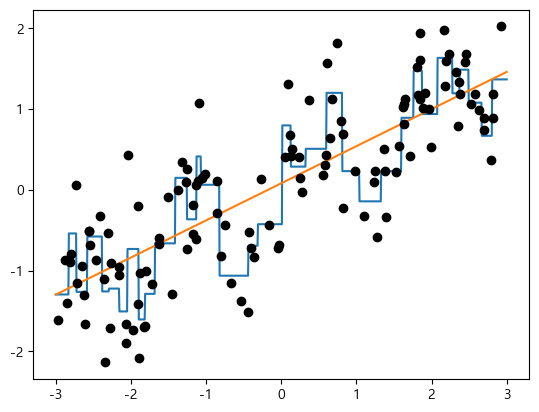

In [75]:
reg = DecisionTreeRegressor(min_samples_leaf=3).fit(X, y)
plt.plot(line, reg.predict(line), label="결정트리")
reg = LinearRegression().fit(X, y)
plt.plot(line, reg.predict(line), label="선형회귀")
plt.plot(X[:, 0], y, 'o', c="k")

In [76]:
from sklearn.preprocessing import KBinsDiscretizer
kb = KBinsDiscretizer(n_bins=10, strategy="uniform", encode='onehot-dense')
kb.fit(X)

KBinsDiscretizer(encode='onehot-dense', n_bins=10, strategy='uniform')

In [77]:
X_binned = kb.transform(X)
line_binned = kb.transform(line)

In [78]:
X_combined = np.hstack([X, X_binned.toarray()])
line_combined = np.hstack([line, line_binned.toarray()])
X_product = np.hstack([X_binned, X * X_binned.reshape(-1,1)])

AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

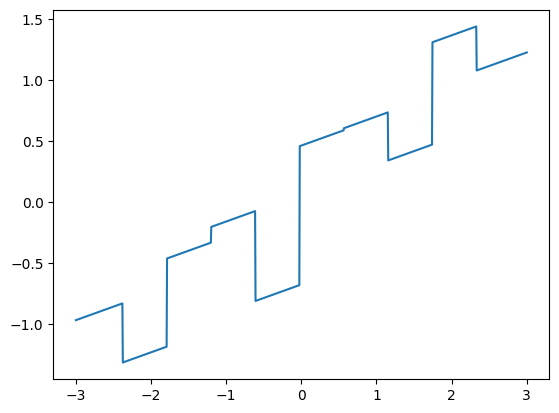

In [ ]:
reg = LinearRegression().fit(X_combined, y)
plt.plot(line, reg.predict(line_combined), label="선형회귀")

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10, include_bias=False) # 지금부터 차수를 10차까지 늘리겠다! 2,3,4,5,...,10
poly.fit(X)
X_poly = poly.transform(X)
X_poly

array([[-7.52759287e-01,  5.66646544e-01, -4.26548448e-01, ...,
         1.03097700e-01, -7.76077513e-02,  5.84199555e-02],
       [ 2.70428584e+00,  7.31316190e+00,  1.97768801e+01, ...,
         2.86036036e+03,  7.73523202e+03,  2.09182784e+04],
       [ 1.39196365e+00,  1.93756281e+00,  2.69701700e+00, ...,
         1.40936394e+01,  1.96178338e+01,  2.73073115e+01],
       ...,
       [-4.37353268e-01,  1.91277881e-01, -8.36560065e-02, ...,
         1.33862524e-03, -5.85452125e-04,  2.56049400e-04],
       [ 1.90808860e+00,  3.64080209e+00,  6.94697294e+00, ...,
         1.75706686e+02,  3.35263923e+02,  6.39713268e+02],
       [ 2.16438350e+00,  4.68455593e+00,  1.01391756e+01, ...,
         4.81585847e+02,  1.04233646e+03,  2.25601584e+03]])

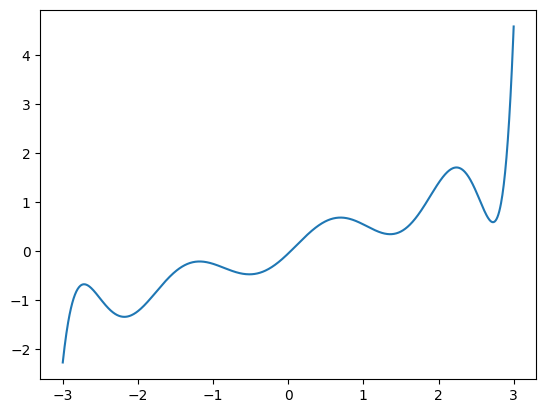

In [ ]:
reg = LinearRegression().fit(X_poly, y)
line_poly = poly.transform(line)
plt.plot(line, reg.predict(line_poly), label="선형회귀")

In [99]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile, f_classif, SelectFromModel # f_classif : 분류에서 쓰는 거
from sklearn.model_selection import train_test_split

In [80]:
cancer = load_breast_cancer()

In [92]:
rng = np.random.RandomState(42) # seed : 난수열의 첫번째 값을 정하나보다 ~
noise = rng.normal(size=(len(cancer.data), 50))
X_w_noise = np.hstack([cancer.data, noise])
X_w_noise.shape

(569, 80)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X_w_noise, cancer.target, random_state=42, test_size=0.5)

In [ ]:
select = SelectPercentile(score_func=f_classif, percentile=50) # 특성을 50% 정도로 해달라
select.fit(X_train, y_train) # y_train : 이것도 같이 넣음, 정답지도 같이 넣어서 자기가 특성 선택하도록
X_train_selected = select.transform(X_train)

([<matplotlib.axis.YTick at 0x2b35c1c32e0>], [Text(0, 0, '0')])

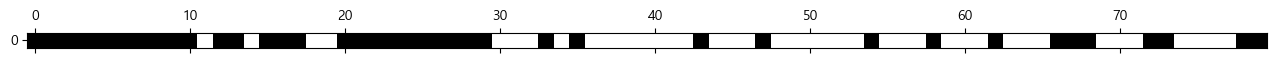

In [96]:
mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap="gray_r")
plt.yticks([0])

In [98]:
from sklearn.linear_model import LogisticRegression

X_test_selected = select.transform(X_test)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
print(lr.score(X_test, y_test))
lr.fit(X_train_selected, y_train)
print(lr.score(X_test_selected, y_test))

0.9614035087719298
0.9649122807017544


In [101]:
from sklearn.ensemble import RandomForestClassifier
select = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold="median"
)

In [106]:
select.fit(X_train, y_train)
X_train_selected = select.transform(X_train)
X_test_selected = select.transform(X_test)

In [107]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
print(lr.score(X_test, y_test))
lr.fit(X_train_selected, y_train)
print(lr.score(X_test_selected, y_test))

0.9614035087719298
0.9543859649122807
